In [1]:
# Lab 10 MNIST and softmax
import torch
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import random

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for reproducibility
random.seed(777)
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

In [3]:
# parameters
learning_rate = 0.001
training_epochs = 15
batch_size = 100

In [4]:
# MNIST dataset
mnist_train = dsets.MNIST(root='MNIST_data/',
                          train=True,
                          transform=transforms.ToTensor(),
                          download=True)

mnist_test = dsets.MNIST(root='MNIST_data/',
                         train=False,
                         transform=transforms.ToTensor(),
                         download=True)

In [5]:
# dataset loader
data_loader = torch.utils.data.DataLoader(dataset=mnist_train,
                                          batch_size=batch_size,
                                          shuffle=True,
                                          drop_last=True)

In [ ]:
# nn layers
linear1 = torch.nn.Linear(784, 512, bias=True)
linear2 = torch.nn.Linear(512, 512, bias=True)
linear3 = torch.nn.Linear(512, 512, bias=True)
linear4 = torch.nn.Linear(512, 512, bias=True)
linear5 = torch.nn.Linear(512, 10, bias=True)
relu = torch.nn.ReLU()

In [9]:
# xavier initialization
torch.nn.init.xavier_uniform_(linear1.weight)
torch.nn.init.xavier_uniform_(linear2.weight)
torch.nn.init.xavier_uniform_(linear3.weight)
torch.nn.init.xavier_uniform_(linear4.weight)
torch.nn.init.xavier_uniform_(linear5.weight)

Parameter containing:
tensor([[ 0.0609,  0.0468, -0.0650,  ...,  0.0986, -0.0188, -0.0318],
        [-0.0608,  0.0482, -0.0718,  ..., -0.0226, -0.0302,  0.0074],
        [-0.0618,  0.0946,  0.0216,  ..., -0.1030,  0.0172,  0.1070],
        ...,
        [ 0.1065, -0.1039,  0.0298,  ..., -0.0079,  0.0018,  0.0794],
        [-0.0266,  0.0046, -0.1046,  ...,  0.0276,  0.0209,  0.0399],
        [-0.0643, -0.0725,  0.0499,  ..., -0.0865, -0.0614,  0.1016]],
       requires_grad=True)

In [10]:
# model
# 수정된 모델 구성
model = torch.nn.Sequential(
    linear1, relu, 
    linear2, relu, 
    linear3, relu, 
    linear4, relu, 
    linear5
).to(device)

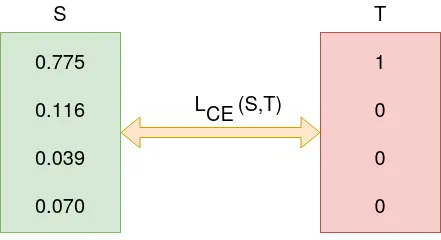

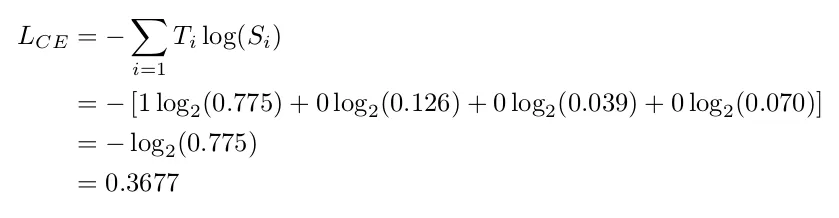

In [11]:
# define cost/loss & optimizer
criterion = torch.nn.CrossEntropyLoss().to(device)    # Softmax is internally computed.
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
total_batch = len(data_loader)
# data_loader 는 60,000장의 데이터를 100장씩 포장해둔 상태이다. 
# 즉 포장된 상자의 개수인 600이 된다.
for epoch in range(training_epochs):# training_epochs = 15 -> 회독수
# 아래의 코드를 15번 반복할 것
    avg_cost = 0

    for X, Y in data_loader:
        # 실제 데이터를 배급하는 과정
        # 600개의 상자를 하나씩 꺼낸다. -> 즉 600번 돌아간다.
        # 밖의 epoch이 1번 실행될 때마다, data_loader 는 첫번째부터 600번째 묶음까지
        # 차례대로 하나씩 꺼내서 안쪽 for 문에 공급한다.   
        # reshape input image into [batch_size by 784]
        # label is not one-hot encoded
        X = X.view(-1, 28 * 28).to(device)
        Y = Y.to(device)

        optimizer.zero_grad()
        hypothesis = model(X)
        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch
        # 각 배치(100장)마다 발생한 cost 값을 합산하여 600으로 나눈다.

    print('Epoch:', '%04d' % (epoch + 1), 'cost =', '{:.9f}'.format(avg_cost))

print('Learning finished')

Epoch: 0001 cost = 0.210202351
Epoch: 0002 cost = 0.094007090
Epoch: 0003 cost = 0.062725194
Epoch: 0004 cost = 0.048729353
Epoch: 0005 cost = 0.041010022
Epoch: 0006 cost = 0.033143330
Epoch: 0007 cost = 0.030270020
Epoch: 0008 cost = 0.025605662
Epoch: 0009 cost = 0.023895347
Epoch: 0010 cost = 0.021413777
Epoch: 0011 cost = 0.019558325
Epoch: 0012 cost = 0.019545874
Epoch: 0013 cost = 0.015850548
Epoch: 0014 cost = 0.015949601
Epoch: 0015 cost = 0.016286690
Learning finished


In [13]:
# Test the model using test sets
with torch.no_grad():
    X_test = mnist_test.test_data.view(-1, 28 * 28).float().to(device)
    Y_test = mnist_test.test_labels.to(device)

    prediction = model(X_test)
    correct_prediction = torch.argmax(prediction, 1) == Y_test
    accuracy = correct_prediction.float().mean()
    print('Accuracy:', accuracy.item())

    # Get one and predict
    r = random.randint(0, len(mnist_test) - 1)
    X_single_data = mnist_test.test_data[r:r + 1].view(-1, 28 * 28).float().to(device)
    Y_single_data = mnist_test.test_labels[r:r + 1].to(device)

    print('Label: ', Y_single_data.item())
    single_prediction = model(X_single_data)
    print('Prediction: ', torch.argmax(single_prediction, 1).item())

Accuracy: 0.9811000227928162
Label:  8
Prediction:  8


c:\Users\hhnur\anaconda3\envs\torch_env\lib\site-packages\torchvision\datasets\mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
c:\Users\hhnur\anaconda3\envs\torch_env\lib\site-packages\torchvision\datasets\mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
